# Implementing the Backpropagation Algorithm

A Multilayer Perceptron Neural Network is trained using the Backpropagation Algorithm on a custom dataset.

## Initializing the Libraries

In [52]:
%pip install numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


# The Dataset

## Splitting the dataset

In [16]:
import numpy as np
import os, csv

# loading the data
DATASET = np.loadtxt(os.path.join("dataset", "data.csv"), delimiter=",")
DATALABELS = np.loadtxt(os.path.join("dataset", "data_labels.csv"), delimiter=",", dtype=int)
TESTSET = np.loadtxt(os.path.join("dataset", "test_set.csv"), delimiter=",")

print(f"DATASET : {DATASET.shape}")
print(f"DATALABELS : {DATALABELS.shape}  classes: {np.unique(DATALABELS)}")
print(f"TESTSET : {TESTSET.shape}")

# encode
CLASSES = int(np.max(DATALABELS))
LABELS = np.zeros((len(DATALABELS), CLASSES), dtype=float)
for _i, label in enumerate(DATALABELS):
    LABELS[_i, int(label) - 1] = 1.0

print(f"LABELS   : {LABELS.shape}")
print(f"Sample   : label {DATALABELS[0]} → {LABELS[0]}")


DATASET : (3486, 354)
DATALABELS : (3486,)  classes: [1 2 3 4 5 6 7 8]
TESTSET : (701, 354)
LABELS   : (3486, 8)
Sample   : label 8 → [0. 0. 0. 0. 0. 0. 0. 1.]


## Batch Size

mini-batch size = 8 by default

In [ ]:
class Network:
    A = {
        'batch_size'  : 8,
        'randomized'  : False,
        'applysmote'  : False,
    }
    B = {
        'batch_size'  : 8,
        'randomized'  : True,
        'applysmote'  : True,
    } #will complete this later

def minibatch(X, D, config):
    N = len(X)
    indices = np.random.permutation(N) if config['randomized'] else np.arange(N)
    for start in range(0, N, config['batch_size']):
        i = indices[start : start + config['batch_size']]
        yield X[i], D[i]

## Dataset Distribution

To observe how balanced or unbalanced the dataset is...

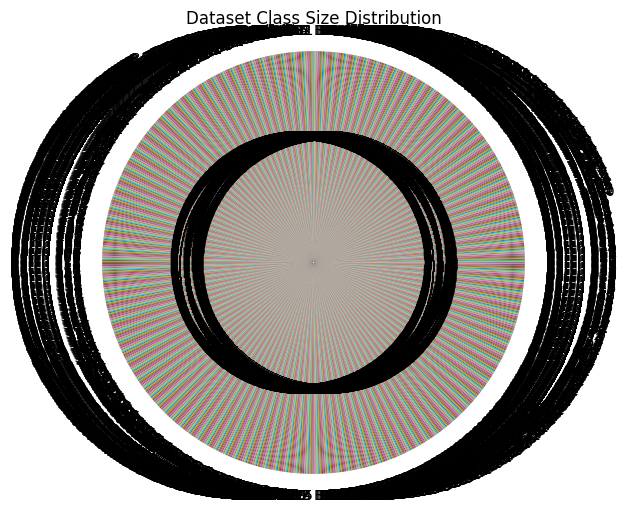

In [18]:
import matplotlib.pyplot as plt

def collect_batch_sizes(X, D, batch_size):
    batch_sizes = []
    for i, (x, d) in enumerate(minibatch(X, D, batch_size, DATA_GLOBALS['randomized'])):
        batch_sizes.append(len(x) * len(d))
    return batch_sizes

# Assuming your data arrays are defined as follows:
X = np.random.rand(10000)  # Example data array of size 10,000
D = np.random.randint(2, size=10000)  # Example labels with size 10,000

# Collect batch sizes for demonstration (assuming each batch has the same number of elements)
batch_sizes = collect_batch_sizes(X, D, DATA_GLOBALS['batch_size'])

# Now we can create a pie chart


def distribution(batch_sizes):
    plt.figure(figsize=(6, 6))
    labels = [f"Batch {i}" for i in range(1, len(batch_sizes) + 1)]
    counts = batch_sizes

    # Normalize to sum of all sizes (for accurate proportions)
    total_size = np.sum(counts)
    normalized_counts = counts / total_size
    plt.pie(normalized_counts, labels=labels, autopct='%1.1f%%', startangle=90)

    # Set title and show the plot
    plt.title('Dataset Class Size Distribution')
    plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
    plt.show()

# Call the function to create and display the pie chart
distribution(batch_sizes)


## SMOTE

In [20]:
from imblearn.over_sampling import SMOTE

class TrainingSplit:
    def __init__(self, X, y, applysmote=True, outputdir="export", valsize=800, randomstate=42):
        os.makedirs(outputdir, exist_ok=True)
        rng = np.random.default_rng(randomstate)
        classes = np.unique(y)
        perclass = valsize // len(classes)

        trainidx, validx = [], []
        for cls in classes:
            clsidx = np.where(y == cls)[0]
            chosen = rng.choice(clsidx, size=perclass, replace=False)
            validx.extend(chosen.tolist())
            trainidx.extend(np.setdiff1d(clsidx, chosen).tolist())

        Xtrain, ytrain = X[np.array(trainidx)], y[np.array(trainidx)]
        Xval,   yval   = X[np.array(validx)],   y[np.array(validx)]

        self.classes      = classes
        self.outputdir    = outputdir
        self.validationset    = Xval
        self.validationlabels = yval

        if applysmote:
            Xtrain, ytrain = self.smote(Xtrain, ytrain, randomstate)

        self.trainingset    = Xtrain
        self.traininglabels = ytrain

        self.exporttrainingset()
        self.exporttraininglabels()
        self.exportvalidationset()
        self.exportvalidationlabels()

    def smote(self, Xtrain, ytrain, randomstate=42):
        print("Before SMOTE:")
        for cls in self.classes:
            print(f"  Class {cls}: {np.sum(ytrain == cls)}")

        Xtrain, ytrain = SMOTE(random_state=randomstate).fit_resample(Xtrain, ytrain)

        print("\nAfter SMOTE:")
        for cls in self.classes:
            print(f"  Class {cls}: {np.sum(ytrain == cls)}")

        return Xtrain, ytrain

    def printdetails(self):
        print("Training Set Details")
        print(f"  Shape       : {self.trainingset.shape}")
        print(f"  Label shape : {self.traininglabels.shape}")
        print(f"  Feature min : {self.trainingset.min():.6f}")
        print(f"  Feature max : {self.trainingset.max():.6f}")
        print(f"  Feature mean: {self.trainingset.mean():.6f}")
        print("\n  Class distribution:")
        total = len(self.traininglabels)
        for cls in self.classes:
            n = np.sum(self.traininglabels == cls)
            print(f"    Class {cls}: {n:>5}  ({n/total*100:.2f}%)")
        print(f"\nValidation Set Details")
        print(f"  Shape       : {self.validationset.shape}")
        print(f"  Label shape : {self.validationlabels.shape}")

    def plotdistribution(self):
        colors = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#1abc9c','#3498db','#9b59b6','#e91e63']

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        fig.patch.set_facecolor('#1a1a2e')
        for ax in axes: ax.set_facecolor('#16213e')

        for ax, labels, title in zip(
            axes,
            [self.traininglabels, self.validationlabels],
            ['Training Set Distribution', 'Validation Set Distribution']
        ):
            counts = [np.sum(labels == cls) for cls in self.classes]
            bars = ax.bar(self.classes, counts, color=colors, edgecolor='white', linewidth=0.6, width=0.7)
            for bar, count in zip(bars, counts):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                        str(count), ha='center', va='bottom', color='white', fontsize=9, fontweight='bold')
            ax.set_title(title, color='white', fontsize=11, pad=8)
            ax.set_xlabel('Class', color='#aaa')
            ax.set_ylabel('Count', color='#aaa')
            ax.tick_params(colors='white')
            ax.spines[:].set_color('#444')
            ax.set_xticks(self.classes)

        plt.tight_layout()
        plt.savefig(os.path.join(self.outputdir, "distribution.png"), dpi=150,
                    bbox_inches='tight', facecolor='#1a1a2e')
        plt.show()
        print(f"Saved → {os.path.join(self.outputdir, 'distribution.png')}")

    def exporttrainingset(self):
        path = os.path.join(self.outputdir, "training_set.csv")
        np.savetxt(path, self.trainingset, delimiter=",", fmt="%g")
        print(f"Saved → {path}  shape: {self.trainingset.shape}")

    def exporttraininglabels(self):
        path = os.path.join(self.outputdir, "training_labels.csv")
        np.savetxt(path, self.traininglabels, delimiter=",", fmt="%d")
        print(f"Saved → {path}  shape: {self.traininglabels.shape}")

    def exportvalidationset(self):
        path = os.path.join(self.outputdir, "validation_set.csv")
        np.savetxt(path, self.validationset, delimiter=",", fmt="%g")
        print(f"Saved → {path}  shape: {self.validationset.shape}")

    def exportvalidationlabels(self):
        path = os.path.join(self.outputdir, "validation_labels.csv")
        np.savetxt(path, self.validationlabels, delimiter=",", fmt="%d")
        print(f"Saved → {path}  shape: {self.validationlabels.shape}")

ModuleNotFoundError: No module named 'imblearn'

# Setting up the Equations

The backpropagation algorithm...

## Full Equation Reference: Backpropagation Algorithm

> **Notation**
> | Symbol | Meaning |
> |--------|---------|
> | $L$ | Total number of layers (output layer index) |
> | $l$ | Current layer index, $l \in \{1, \dots, L\}$ |
> | $i$ | Index of neuron in layer $l-1$; $i = 0$ is the bias input |
> | $j$ | Index of neuron in layer $l$ |
> | $k$ | Index of neuron in output layer $L$ |
> | $w^{(l)}_{j0}$ | Bias weight of neuron $j$ in layer $l$ (fixed input $\varphi_0 = +1$) |
> | $w^{(l)}_{ji}$ | Weight from neuron $i$ in layer $l-1$ to neuron $j$ in layer $l$ |
> | $v^{(l)}_j$ | Internal activity (pre-activation) of neuron $j$ in layer $l$ |
> | $\varphi_j$ | Activation function of neuron $j$; output $\varphi_j\!\left(v^{(l)}_j\right)$ |
> | $d_k$ | Desired (target) output for output neuron $k$ |
> | $e_k(n)$ | Error at output neuron $k$ at epoch $n$ |
> | $\mathcal{E}(n)$ | Mean square error over all output neurons at epoch $n$ |
> | $\eta$ | Learning rate |
> | $\alpha$ | Momentum coefficient |
> | $\gamma$ | Leaky ReLU negative-side slope, $\gamma \in (0,1)$ |
> | $n$ | Discrete time step (epoch) |
 
---

## 1. Forward Propagation to get internal activity $v(n)$ and outputs $y_{out}$

### 1.1 Internal Activity
 
The sum begins at $i = 0$ to include the bias weight $w^{(l)}_{j0}$ directly. The bias neuron has a fixed output of $+1$, so $w^{(l)}_{j0} \cdot 1 = w^{(l)}_{j0}$:
 
$$v^{(l)}_j(n) = \sum_{i=0}^{p} w^{(l)}_{ji}(n)\, \varphi_i\!\left(v^{(l-1)}_i(n)\right)$$
 
where $p$ is the number of neurons in layer $l-1$ (excluding the bias), and the bias input is $\varphi_0 = +1$ (constant).
 
### 1.2 Neuron Output
 
$$\varphi_j\!\left(v^{(l)}_j(n)\right)$$
 
where $\varphi_j$ is the chosen activation function (see Section 2).

## 2. Choosing the Activation Functions
 
Derivatives are expressed in terms of the neuron output $o(n) = \varphi(v(n))$ directly, using constants $a$ and $b$ where applicable.
 
### 2.1 Logistic (Sigmoid)
 
$$\varphi(v) = \frac{1}{1 + e^{-av}}, \quad a > 0$$
 
**Derivative (in terms of output $o(n) = \varphi(v(n))$):**
 
$$\varphi'(v) = a \cdot o(n)\,\bigl(1 - o(n)\bigr)$$

> Given: $a = 2.0$
 
---
 
### 2.2 Hyperbolic Tangent (Tanh)
 
$$\varphi(v) = a \tanh(bv) = a \cdot \frac{e^{bv} - e^{-bv}}{e^{bv} + e^{-bv}}$$
 
**Derivative (in terms of output $o(n) = \varphi(v(n))$):**
 
$$\varphi'(v) = \frac{b}{a}\left(a - o(n)\right)\!\left(a + o(n)\right)$$
 
> Given: $a = 1.716,\; b = 2/3$ (Le Cun's Parameters).
 
---
 
### 2.3 Leaky ReLU
 
$$\varphi(v) = \begin{cases} v & \text{if } v > 0 \\ \gamma\, v & \text{if } v \leq 0 \end{cases}, \quad \gamma \in (0,1)$$
 
**Derivative (in terms of output $o(n) = \varphi(v(n))$):**
 
$$\varphi'(v) = \begin{cases} 1 & \text{if } o(n) > 0 \\ \gamma & \text{if } o(n) \leq 0 \end{cases}$$
 
---

## 3. Error & Mean Square Error
 
### 3.1 Error Signal at Output Neuron $k$
 
$$e_k(n) = d_k(n) - \varphi_k\!\left(v^{(L)}_k(n)\right)$$
 
### 3.2 Mean Square Error
 
$$\mathcal{E}(n) = \frac{1}{2} \sum_{k \in \mathcal{C}} e_k^2(n)$$
 
where $\mathcal{C}$ is the set of output neurons.
 
---

## 4. Backpropagation Delta Equations
 
### 4.1 Output Layer Delta
 
$$\delta^{(L)}_k(n) = e_k(n) \cdot \varphi'\!\left(v^{(L)}_k(n)\right)$$
 
### 4.2 Hidden Layer Delta
 
For layer $l \in \{L-1,\, L-2,\, \dots,\, 1\}$:
 
$$\delta^{(l)}_j(n) = \varphi'\!\left(v^{(l)}_j(n)\right) \cdot \sum_{k}\, \delta^{(l+1)}_k(n)\, w^{(l+1)}_{kj}(n)$$
 
The hidden-layer delta propagates the error signal backward by weighting each upstream delta $\delta^{(l+1)}_k$ by the corresponding weight $w^{(l+1)}_{kj}$ and scaling by the local derivative $\varphi'(v^{(l)}_j)$.
 
---

## 5. Weight Update: Negative Gradient with Momentum
 
All weights $w^{(l)}_{ji}$ include the bias weights at $i = 0$ (with fixed input $\varphi_0 = +1$). No separate bias update is needed.
 
The weight correction follows the **negative gradient** of $\mathcal{E}(n)$ with respect to $w^{(l)}_{ji}$:
 
$$-\frac{\partial \mathcal{E}(n)}{\partial w^{(l)}_{ji}(n)} = \delta^{(l)}_j(n) \cdot \varphi_i\!\left(v^{(l-1)}_i(n)\right)$$
 
### 5.1 Weight Increment (Generalized Delta Rule + Momentum)
 
$$\Delta w^{(l)}_{ji}(n) = \underbrace{\alpha\, \Delta w^{(l)}_{ji}(n-1)}_{\text{momentum}} \;-\; \underbrace{\eta\, \frac{\partial \mathcal{E}(n)}{\partial w^{(l)}_{ji}(n)}}_{\text{negative gradient}}$$
 
Substituting the gradient expression:
 
$$\Delta w^{(l)}_{ji}(n) = \alpha\, \Delta w^{(l)}_{ji}(n-1) \;+\; \eta\, \delta^{(l)}_j(n)\, \varphi_i\!\left(v^{(l-1)}_i(n)\right)$$
 
### 5.2 Weight Update Rule
 
$$w^{(l)}_{ji}(n+1) = w^{(l)}_{ji}(n) + \Delta w^{(l)}_{ji}(n)$$
 
> **Bias weights** ($i = 0$) are updated identically using $\varphi_0 = +1$, so:
> $$\Delta w^{(l)}_{j0}(n) = \alpha\, \Delta w^{(l)}_{j0}(n-1) \;+\; \eta\, \delta^{(l)}_j(n)$$
 
> **Momentum note:** When $\alpha = 0$, this reduces to the standard (vanilla) delta rule. When $\alpha > 0$, the update accumulates a fraction of the previous step, smoothing oscillations and accelerating convergence along consistent gradient directions.
 
---

In [ ]:
#hyperparameters updated
class Network:
    A = {
        'methods'    : [1, 1, 0],  # [i, j, k] — 0 logistic, 1 tanh, 2 relu
        'a_l'        : 1.0,        # logistic slope
        'a_tanh'     : 1.716,      # tanh a
        'b_tanh'     : 0.66666,    # tanh b
        'a_relu'     : 0.01,       # leaky relu gamma
        'eta'        : 0.85,       # learning rate
        'alpha'      : 0.9,        # momentum constant
        'size'       : 8,          # hidden layer size
        'batch_size' : 8,          # from before, keeping it for consistency
        'randomized' : False,      # from before, keeping it for consistency
        'applysmote' : False,      # from before, keeping it for consistency
    }
    B = {
        'methods'    : [2, 2, 0],
        'a_l'        : 1.0,
        'a_tanh'     : 1.716,
        'b_tanh'     : 0.66666,
        'a_relu'     : 0.01,
        'eta'        : 0.85,
        'alpha'      : 0.9,
        'size'       : 8,
        'batch_size' : 8,
        'randomized' : True,
        'applysmote' : True,
    }
 
# ACTIVATION FUNCTIONS

def logistic(v, a=1.0):
    phi = 1.0 / (1.0 + np.exp(-a * v))
    return phi

def tanh(v, a=1.0, b=1.0):
    phi = a * np.tanh(b * v)
    return phi
 
def leakyrelu(v, gamma=0.01):
    phi = np.where(v > 0, v, gamma * v)
    return phi
 
def errorSignal(dk, phiVk):
    return dk - phiVk
 
def meanSquareError(ek):
    return 0.5 * np.dot(ek, ek)

# DERIVATIVES
RELU_CLIP = 5.0 #for relu to converge

def dlogistic(o, a=1.0):
    dphi = a * o * (1.0 - o)
    return dphi
 
def dtanh(o, a=1.0, b=1.0):
    dphi = (b / a) * (a - o) * (a + o)
    return dphi
 
def dleakyrelu(o, gamma=0.01):
    dphi = np.where(o > 0, 1.0, gamma)
    return dphi
 
# DERIVATIVE CALL
def callDerivative(method, o, config):
    if method == 0:
        return dlogistic(o, config['a_l']), None
    elif method == 1:
        return dtanh(o, config['a_tanh'], config['b_tanh']), None
    else:
        return dleakyrelu(o, config['a_relu']), RELU_CLIP
 
# ACTIVATION CALL
def callActivation(method, v, config):
    if method == 0:
        return logistic(v, config['a_l'])
    elif method == 1:
        return tanh(v, config['a_tanh'], config['b_tanh'])
    else:
        return leakyrelu(v, config['a_relu'])

Run the code below to initialize the classes for the layers and epochs.

In [23]:
class OutputLayer:
    def __init__(self, method, size, w_old, config, dw_prev=None):
        self.config = config
        self.method = method
        self.v = []
        self.o = []
        self.d = []
        self.w_old = w_old
        self.size = size
        self.delta = []
        self.error = []
        self.mse = 0.0
        self.w_new = []
 
        self.dw_prev = dw_prev if dw_prev is not None else np.zeros_like(w_old)
        self.phiIn = None
        self.gradient = np.zeros_like(w_old)
 
    def forward(self, phiIn):
        self.phiIn = phiIn
        self.v = self.w_old @ phiIn
        self.o = callActivation(self.method, self.v, self.config)
 
    def computeError(self, d):
        self.d = np.asarray(d, dtype=float)
        self.error = errorSignal(self.d, self.o)
        self.mse = meanSquareError(self.error)
 
    def computeDelta(self):
        dphi, _ = callDerivative(self.method, self.o, self.config)
        self.delta = self.error * dphi
 
    def accumulateGradient(self):
        self.gradient += np.outer(self.delta, self.phiIn)
 
    def resetGradient(self):
        self.gradient = np.zeros_like(self.w_old)
 
    def updateWeights(self, batch_size=1):
        dw = self.config['alpha'] * self.dw_prev + self.config['eta'] * (self.gradient / batch_size)
        self.w_new = self.w_old + dw
        self.dw_prev = dw
        self.gradient = np.zeros_like(self.w_old)
 
 
class HiddenLayer:
    def __init__(self, method, w_old, config, size=8, dw_prev=None):
        self.config = config
        self.method = method
        self.v = []
        self.y = []
        self.w_old = w_old
        self.size = size
        self.delta = 0.0
        self.w_new = []
 
        self.dw_prev = dw_prev if dw_prev is not None else np.zeros_like(w_old)
        self.phiIn = None
        self.gradient = np.zeros_like(w_old)
 
    def forward(self, phiIn):
        self.phiIn = phiIn
        self.v = self.w_old @ phiIn
        self.y = callActivation(self.method, self.v, self.config)
        return np.concatenate(([1.0], self.y))
 
    def computeDelta(self, nextLayer):
        dphi, _ = callDerivative(self.method, self.y, self.config)
        w_nobias = nextLayer.w_old[:, 1:]
        propagated = w_nobias.T @ nextLayer.delta
        self.delta = dphi * propagated
 
    def accumulateGradient(self):
        self.gradient += np.outer(self.delta, self.phiIn)
 
    def resetGradient(self):
        self.gradient = np.zeros_like(self.w_old)
 
    def updateWeights(self, batch_size=1):
        dw = self.config['alpha'] * self.dw_prev + self.config['eta'] * (self.gradient / batch_size)
        _, clip = callDerivative(self.method, self.y, self.config)
        if clip is not None:
            norm = np.linalg.norm(dw)
            if norm > clip:
                dw = dw * (clip / norm)
        self.w_new = self.w_old + dw
        self.dw_prev = dw
        self.gradient = np.zeros_like(self.w_old)
        return self.w_new
 
 
class Epoch:
    def __init__(self, hiddenlayer_i, hiddenlayer_j, outputlayer_k, config):
        self.config = config
        self.hiddenlayer_i = hiddenlayer_i
        self.hiddenlayer_j = hiddenlayer_j
        self.outputlayer_k = outputlayer_k
 
        self.test_set = []
        self.validation_set = []
        self.error = 0.0
        self.iteration = 1
 
        self.tp = 0.0
        self.tn = 0.0
        self.fp = 0.0
        self.fn = 0.0
        self.p = 0.0
        self.r = 0.0
        self.a = 0.0
        self.f1 = 0.0
        self.matthews = 0.0
 
    def run(self, x, d):
        x_biased = np.concatenate(([1.0], np.asarray(x, dtype=float)))
 
        # Forward Prop
        phi_i = self.hiddenlayer_i.forward(x_biased)
        phi_j = self.hiddenlayer_j.forward(phi_i)
        self.outputlayer_k.forward(phi_j)
 
        # Error calcs
        self.outputlayer_k.computeError(d)
        self.error = self.outputlayer_k.mse
 
        # Backprop
        self.outputlayer_k.computeDelta()
        self.hiddenlayer_j.computeDelta(self.outputlayer_k)
        self.hiddenlayer_i.computeDelta(self.hiddenlayer_j)
 
        # Accumulate (batch_size=1, so gradient = outer(delta, phiIn))
        self.outputlayer_k.accumulateGradient()
        self.hiddenlayer_j.accumulateGradient()
        self.hiddenlayer_i.accumulateGradient()
 
        # Weight updates
        self.outputlayer_k.updateWeights()
        self.hiddenlayer_j.updateWeights()
        self.hiddenlayer_i.updateWeights()
 
        # Advance w_old → w_new
        self.outputlayer_k.w_old = self.outputlayer_k.w_new
        self.hiddenlayer_j.w_old = self.hiddenlayer_j.w_new
        self.hiddenlayer_i.w_old = self.hiddenlayer_i.w_new
 
        self.iteration += 1
 
    def run_batch(self, X_batch, D_batch):
        batch_size = len(X_batch)
        error = 0.0
 
        for SAMPLE in range(batch_size):
            x_biased = np.concatenate(([1.0], np.asarray(X_batch[SAMPLE], dtype=float)))
 
            # Forward Prop
            phi_i = self.hiddenlayer_i.forward(x_biased)
            phi_j = self.hiddenlayer_j.forward(phi_i)
            self.outputlayer_k.forward(phi_j)
 
            # Error calcs
            self.outputlayer_k.computeError(D_batch[SAMPLE])
            error += self.outputlayer_k.mse
 
            # Backprop
            self.outputlayer_k.computeDelta()
            self.hiddenlayer_j.computeDelta(self.outputlayer_k)
            self.hiddenlayer_i.computeDelta(self.hiddenlayer_j)
 
            # Accumulate
            self.outputlayer_k.accumulateGradient()
            self.hiddenlayer_j.accumulateGradient()
            self.hiddenlayer_i.accumulateGradient()
 
        # Weight updates — gradient averaged over batch inside updateWeights
        self.outputlayer_k.updateWeights(batch_size)
        self.hiddenlayer_j.updateWeights(batch_size)
        self.hiddenlayer_i.updateWeights(batch_size)
 
        # Advance w_old → w_new
        self.outputlayer_k.w_old = self.outputlayer_k.w_new
        self.hiddenlayer_j.w_old = self.hiddenlayer_j.w_new
        self.hiddenlayer_i.w_old = self.hiddenlayer_i.w_new
 
        self.error = error / batch_size
        self.iteration += 1
        return self.error
 
    def Scores(self, threshold=0.5):
        self.tp = 0.0
        self.tn = 0.0
        self.fp = 0.0
        self.fn = 0.0
 
        for x, d in self.test_set:
            x_biased = np.concatenate(([1.0], np.asarray(x, dtype=float)))
            phi_i = self.hiddenlayer_i.forward(x_biased)
            phi_j = self.hiddenlayer_j.forward(phi_i)
            self.outputlayer_k.forward(phi_j)
 
            predicted = int(self.outputlayer_k.o[0] >= threshold)
            actual = int(d[0])
 
            if   predicted == 1 and actual == 1:  self.tp += 1.0
            elif predicted == 0 and actual == 0:  self.tn += 1.0
            elif predicted == 1 and actual == 0:  self.fp += 1.0
            elif predicted == 0 and actual == 1:  self.fn += 1.0
 
        self.p = self.tp / (self.tp + self.fp) if (self.tp + self.fp) > 0 else 0.0
        self.r = self.tp / (self.tp + self.fn) if (self.tp + self.fn) > 0 else 0.0
        self.f1 = (2 * self.p * self.r / (self.p + self.r)) if (self.p + self.r) > 0 else 0.0
 
        total = self.tp + self.tn + self.fp + self.fn
        self.a = (self.tp + self.tn) / total if total > 0 else 0.0
 
        denom = np.sqrt((self.tp + self.fp) * (self.tp + self.fn) *
                                (self.tn + self.fp) * (self.tn + self.fn))
        self.matthews = (self.tp * self.tn - self.fp * self.fn) / denom if denom > 0 else 0.0
 
    def printScores(self):
        print("┌──────────────────────────────────┐")
        print("│         Confusion Matrix          │")
        print(f"│  TP: {self.tp:6.0f}      FP: {self.fp:6.0f}  │")
        print(f"│  FN: {self.fn:6.0f}      TN: {self.tn:6.0f}  │")
        print("├──────────────────────────────────┤")
        print(f"│  Error (MSE) : {self.error:.5f}           │")
        print(f"│  Accuracy    : {self.a:.5f}           │")
        print(f"│  Precision   : {self.p:.5f}           │")
        print(f"│  Recall      : {self.r:.5f}           │")
        print(f"│  F1 Score    : {self.f1:.5f}           │")
        print(f"│  Matthews CC : {self.matthews:.5f}           │")
        print("└──────────────────────────────────┘")
 
    def exportErrors(self, filepath="export/errors.csv"):
        os.makedirs(os.path.dirname(filepath), exist_ok=True)
        writeHeader = not os.path.exists(filepath) or os.path.getsize(filepath) == 0
        with open(filepath, 'a', newline='') as f:
            writer = csv.writer(f)
            if writeHeader:
                writer.writerow(['iteration', 'error'])
            writer.writerow([self.iteration, self.error])
 
    def exportScores(self, filepath="export/scores.csv"):
        os.makedirs(os.path.dirname(filepath), exist_ok=True)
        writeHeader = not os.path.exists(filepath) or os.path.getsize(filepath) == 0
        with open(filepath, 'a', newline='') as f:
            writer = csv.writer(f)
            if writeHeader:
                writer.writerow(['iteration', 'accuracy', 'precision', 'recall', 'f1', 'matthews'])
            writer.writerow([self.iteration, self.a, self.p, self.r, self.f1, self.matthews])


In [ ]:
# DEMO, run non-vectorized just to see if it works

G = Network.A
 
# G = GLOBAL # for default global
 
if __name__ == "__main__":
    np.random.seed(42)
 
    X  = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
    Dk = np.array([[0],  [1],  [1],  [0]],  dtype=float)
 
    rng = np.random.default_rng(42)
    def initW(rows, cols):
        limit = np.sqrt(6.0 / (rows + cols))
        w = rng.uniform(-limit, limit, size=(rows, cols))
        w[:, 0] = 0.0
        return w
 
    hiddenI = HiddenLayer(G['methods'][0], initW(4, 3), G, G['size'])
    hiddenJ = HiddenLayer(G['methods'][1], initW(4, 5), G, G['size'])
    outputK = OutputLayer(G['methods'][2], 1, initW(1, 5), G)
 
    epochRunner = Epoch(hiddenI, hiddenJ, outputK, G)
 
    for ep in range(1, 5001):
        totalMse = 0.0
        for i in np.random.permutation(len(X)):
            epochRunner.run(X[i], Dk[i])
            totalMse += epochRunner.error
        epochRunner.error = totalMse
        epochRunner.exportErrors()
        if ep % 500 == 0:
            print(f"Epoch {ep:5d}  |  Error(n): {totalMse:.6f}")
 
    print("\nFinal predictions:")
    for xi, di in zip(X, Dk):
        xb    = np.concatenate(([1.0], xi))
        phi_i = hiddenI.forward(xb)
        phi_j = hiddenJ.forward(phi_i)
        outputK.forward(phi_j)
        print(f"  Input {xi}  →| Predicted {outputK.o[0]:.4f}  (Desired {di[0]})")
 
    epochRunner.test_set = list(zip(X, Dk))
    epochRunner.Scores()
    epochRunner.printScores()
    epochRunner.exportScores()

NameError: name 'configG' is not defined

# Training Phase

# Implementation



# Results

# Conclusion